In [1]:
pip install cryptography lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn joblib tensorflow pillow --quiet

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import os, warnings, hashlib, logging, json, joblib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from time import time

from cryptography.fernet import Fernet 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2   #pretrained CNN Model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input  #image ko mobilevnet2 ke required format mai convert krta hai
from tensorflow.keras.preprocessing import image as keras_image  #to read image

np.random.seed(42) #har baar same random values generate hongi
tf.random.set_seed(42)  #tensorflow ke random initialization ko fix krta hai
plt.rcParams['figure.dpi'] = 120   #graphs ki quality set krta hai
sns.set_style('whitegrid')

SEED = 42
TARGET_COLS = ['stunted', 'wasted', 'underweight']


In [3]:
from sklearn.metrics import (
confusion_matrix, classification_report,roc_auc_score, f1_score,accuracy_score, balanced_accuracy_score, matthews_corrcoef,
average_precision_score
)
def detailed_metrics (y_true, y_pred, y_prob, target_name):
    #y_true - actual/real labels
    #y_pred - model ne jo final class predict ki (0 ya 1)
    #y_prob -  model ne jo raw probability di 
    #target_name - kis target ke liye ye metrics hain
    """
    Saare important metrics calculate karo ek saath
    """

    tn,fp,fn,tp = confusion_matrix(y_true, y_pred).ravel()  #ravel converts it into [TN,FP,FN,TP]
    #confusion matrix ek 2*2 table bnata hai

    accuracy = (tp+tn)/(tp+tn+fp+fn)
    balanced_acc = balanced_accuracy_score(y_true,y_pred)   #balanced_acc = (sensitivity+specificity)/2

    sensitivity = tp/(tp+fn)
    tpr = sensitivity

    specificity = tn/(tn+fp)
    tnr = specificity

    precision = tp/(tp+fp)
    ppv = precision

    npv = tn/(tn+fn)

    fpr = fp/(fp+tn)   #1-specificity = FPR
    fnr = fn/(fn+tp)     #1-Sensitivity

    f1 = f1_score(y_true,y_pred)     #balances precision and recall equally
    f2 = (5*precision*sensitivity) / (4*precision+sensitivity)   #f2 gives more importance to recall than precision.
    #Useful in healthcare because missing a patient is worse than a false alarm.

    mcc = matthews_corrcoef(y_true,y_pred)   #very useful for imbalanced datasets.

    roc_auc = roc_auc_score(y_true,y_prob)  #measures model's ability to seperate positive and negative classes.

    pr_auc = average_precision_score(y_true,y_prob)  #more informative than ROC-AUC when the positive class is rare (imbalanced datasets).

    lr_plus = sensitivity / fpr if fpr>0 else float('inf')   #likelihood ratio positive, higher values are better.
    lr_minus = fnr/specificity if specificity>0 else float('inf')
    print(f"\n{'='*55}")
    print(f"  METRICS — {target_name.upper()}")
    print(f"{'='*55}")
    print(f"\n  Confusion Matrix:")
    print(f"\n  ── Performance Metrics ──")
    print(f"  Accuracy          : {accuracy*100:.2f}%")
    print(f"  Balanced Accuracy : {balanced_acc*100:.2f}%")
    print(f"  F1 Score          : {f1:.4f}")
    print(f"  F2 Score          : {f2:.4f}")
    print(f"  MCC               : {mcc:.4f}")

    print(f"\n  ── Sensitivity / Specificity ──")
    print(f"  Sensitivity (TPR) : {sensitivity:.4f}  ({sensitivity*100:.2f}%)")
    print(f"  Specificity (TNR) : {specificity:.4f}  ({specificity*100:.2f}%)")
    print(f"  FPR               : {fpr:.4f}  ({fpr*100:.2f}%)")
    print(f"  FNR               : {fnr:.4f}  ({fnr*100:.2f}%)")

    print(f"\n  ── Predictive Values ──")
    print(f"  PPV (Precision)   : {ppv:.4f}  ({ppv*100:.2f}%)")
    print(f"  NPV               : {npv:.4f}  ({npv*100:.2f}%)")

    print(f"\n  ── AUC Scores ──")
    print(f"  ROC-AUC           : {roc_auc:.4f}")
    print(f"  PR-AUC            : {pr_auc:.4f}")

    print(f"\n  ── Likelihood Ratios ──")
    print(f"  LR+               : {lr_plus:.4f}")
    print(f"  LR-               : {lr_minus:.4f}")

    return {
            'Target':           target_name,
            'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'Accuracy':         round(accuracy, 4),
            'Balanced Accuracy':round(balanced_acc, 4),
            'Sensitivity (TPR)':round(sensitivity, 4),
            'Specificity (TNR)':round(specificity, 4),
            'PPV (Precision)':  round(ppv, 4),
            'NPV':              round(npv, 4),
            'FPR':              round(fpr, 4),
            'FNR':              round(fnr, 4),
            'F1 Score':         round(f1, 4),
            'F2 Score':         round(f2, 4),
            'MCC':              round(mcc, 4),
            'ROC-AUC':          round(roc_auc, 4),
            'PR-AUC':           round(pr_auc, 4),
            'LR+':              round(lr_plus, 4),
            'LR-':              round(lr_minus, 4),
        }

In [4]:
KEY_FILE = 'secret4.key'

if os.path.exists(KEY_FILE):
    with open(KEY_FILE, 'rb') as f:
        key = f.read()
    print("Key load ho gayi!")
else:
    key = Fernet.generate_key()
    with open(KEY_FILE, 'wb') as f:
        f.write(key)
    print("Naya key bana!")

fernet = Fernet(key)
print(" secret.key kabhi delete mat karna!")

Naya key bana!
 secret.key kabhi delete mat karna!


In [5]:
LOG_FILE = 'audit_log4.txt'
logging.basicConfig(
    filename=LOG_FILE, level=logging.INFO,
    format='%(asctime)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger('malnutrition_pipeline')

def log(msg):
    logger.info(msg)
    print(f"[LOG] {msg}")

log("Pipeline shuru hua")
print(f"Audit log ready: {LOG_FILE}")

[LOG] Pipeline shuru hua
Audit log ready: audit_log4.txt


In [6]:

TABULAR_PATH     = r'malnutrition_child_dataset_final.csv'
# MALNUTRITION_DIR = r'Malnutrition'
# NUTRITION_DIR= r'Nutrition'
MALNUTRITION_DIR = r'folder/Malnutrition' 
NUTRITION_DIR     = r'folder/Nutrition'

df_raw = pd.read_csv(TABULAR_PATH)
log(f"Dataset load hua | Rows: {df_raw.shape[0]:,} | Cols: {df_raw.shape[1]}")
print(f"Shape: {df_raw.shape}")

# SHA-256 Hashing — IDs anonymous
#hashinf converts the input into the 256 length bit output (jo hex mai 64 characters
#ka string dikhta hai)


def hash_id(v):
    return hashlib.sha256(str(v).encode()).hexdigest()[:16]
#it is converting IDs into string
#String is converted into bytes
#later hashing is done and only 16 bytes are taken from the full generate hash value

df_raw['child_id_anon'] = [hash_id(i) for i in df_raw.index]
#dataset ke har row index ko hash krke ek nye column child_id_anon bnaya jaa rha hai.

print("IDs anonymous ho gayi!")

[LOG] Dataset load hua | Rows: 232,920 | Cols: 28
Shape: (232920, 28)
IDs anonymous ho gayi!


In [7]:
SENSITIVE_COLS = ['mother_age', 'mother_bmi', 'mother_education']

def encrypt_value(v, f):
    return f.encrypt(str(v).encode()).decode()

df_enc = df_raw.copy()
for col in SENSITIVE_COLS:
    df_enc[col] = df_enc[col].apply(lambda x: encrypt_value(x, fernet))

df_enc.to_csv('encrypted_dataset.csv', index=False) #encrypted dataset is saved in different file
log(f"Columns encrypt hue: {SENSITIVE_COLS}")
print(" Encrypted dataset save hua!")

[LOG] Columns encrypt hue: ['mother_age', 'mother_bmi', 'mother_education']
 Encrypted dataset save hua!


In [8]:
FLAG_CODES = [9996, 9997, 9998, 9999]

df_v2 = df_raw.copy()

for col in ['stunting_zscore', 'wasting_zscore', 'underweight_zscore']:
    df_v2[col] = df_v2[col].replace(FLAG_CODES, np.nan)

df_v2['stunted']     = (df_v2['stunting_zscore']    < -200).astype(int) #true- 1 (stunted hai)(at risk)
df_v2['wasted']      = (df_v2['wasting_zscore']     < -200).astype(int)
df_v2['underweight'] = (df_v2['underweight_zscore'] < -200).astype(int)

df_v2 = df_v2.dropna(subset=['stunting_zscore','wasting_zscore','underweight_zscore'])  #missing (NaN) values remove krta hai
df_v2 = df_v2.drop(columns=['stunting_zscore','wasting_zscore','underweight_zscore']) #ye columns remove krta hai

for col in ['urban_rural.1','child_age_years','child_id_anon']:
    if col in df_v2.columns:
        df_v2 = df_v2.drop(columns=[col]) #leakage columns removed

log(f"Data clean | Rows: {len(df_v2):,}")
print(f" Clean data: {df_v2.shape}")
print(f"weight_kg hai?     {'weight_kg' in df_v2.columns}")  #encrypt nhi kiya kyuki ML Model ko chahiye or ye direct PII nahi
print(f"height_cm hai?     {'height_cm' in df_v2.columns}")
print(f"child_bmi_raw hai? {'child_bmi_raw' in df_v2.columns}")

for t in TARGET_COLS:
    print(f"  {t:12s}: {df_v2[t].sum():,} positive ({df_v2[t].mean()*100:.1f}%)")

[LOG] Data clean | Rows: 198,802
 Clean data: (198802, 26)
weight_kg hai?     True
height_cm hai?     True
child_bmi_raw hai? True
  stunted     : 71,347 positive (35.9%)
  wasted      : 58,301 positive (29.3%)
  underweight : 36,857 positive (18.5%)


In [9]:
# FEATURE_COLS = [
#     'child_age_months','gender','birth_weight',
#     'weight_kg','height_cm','child_bmi_raw',
#     'breastfeeding','diarrhea','fever','cough',
#     'mother_age','mother_education','mother_bmi',
#     'children_ever_born','birth_order','household_members',
#     'urban_rural','wealth_index',
#     'water_source','time_to_water',
#     'sanitation_toilet_facility','handwashing_facility',
#     'antenatal_visits'
# ]
# FEATURE_COLS = [c for c in FEATURE_COLS if c in df_v2.columns]

# X_tab = df_v2[FEATURE_COLS].fillna(df_v2[FEATURE_COLS].median())
# y_tab = df_v2[TARGET_COLS]

# print(f"Features : {X_tab.shape[1]}")
# print(f"Samples  : {X_tab.shape[0]:,}")
# print(FEATURE_COLS)

# 1) Features aur targets — df_v2 se (SAHI)
FEATURE_COLS = [
    'child_age_months','gender','birth_weight',
    'weight_kg','height_cm','child_bmi_raw',
    'breastfeeding','diarrhea','fever','cough',
    'mother_age','mother_education','mother_bmi',
    'children_ever_born','birth_order','household_members',
    'urban_rural','wealth_index',
    'water_source','time_to_water',
    'sanitation_toilet_facility','handwashing_facility',
    'antenatal_visits'
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_v2.columns]
X_tab = df_v2[FEATURE_COLS].fillna(df_v2[FEATURE_COLS].median())
y_tab = df_v2[TARGET_COLS]
print(f"Features : {X_tab.shape[1]}")
print(f"Samples  : {X_tab.shape[0]:,}")

# 2) Train/test split (SAHI)
X_train, X_test, y_train, y_test = train_test_split(
    X_tab, y_tab,
    test_size=0.2, random_state=SEED,
    stratify=y_tab['stunted']
)
log(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# 3) DP noise (SAHI)
EPSILON = 1.0
def apply_dp_noise(X_arr, epsilon):
    noise = np.random.laplace(0, 1.0/epsilon, X_arr.shape)
    return X_arr + noise

X_train_dp = apply_dp_noise(X_train.values, EPSILON)
X_test_dp  = apply_dp_noise(X_test.values,  EPSILON)
log(f"DP applied | epsilon={EPSILON}")


Features : 23
Samples  : 198,802
[LOG] Train: 159,041 | Test: 39,761
[LOG] DP applied | epsilon=1.0


In [10]:
print("="*55)
print("  TABULAR ONLY — LightGBM")
print("="*55)

tabular_models  = {}
#har target ka trained model store krega 
tabular_results = {}
#har target ki metrics store krega
for t in TARGET_COLS:  #why loop? teeno targets ke liye same code
    print(f"\nTraining: {t}...", end=' ', flush=True)
    t0 = time()

    model = LGBMClassifier(   #200 decision trees banao, har tree mein max 6 levels
        #har tree 10% contribute krta hai #verbose -> training progress print mt kro
        n_estimators=200, max_depth=6,
        learning_rate=0.1, class_weight='balanced',
        random_state=SEED, verbose=-1, n_jobs=-1
    )
    model.fit(X_train, y_train[t])

    y_pred = model.predict(X_test)  #prediction - 0 ya 1
    y_prob = model.predict_proba(X_test)[:,1] #soft prediction - probability like 70% stunted,
    acc = accuracy_score(y_test[t], y_pred)
    f1  = f1_score(y_test[t], y_pred)
    auc = roc_auc_score(y_test[t], y_prob)

    tabular_models[t]  = model
    tabular_results[t] = {'accuracy':acc, 'f1':f1, 'auc':auc}

    print(f"Done ({round(time()-t0,1)}s)")
    print(f"   Accuracy : {acc*100:.2f}%")
    print(f"   F1 Score : {f1:.4f}")
    print(f"   ROC-AUC  : {auc:.4f}")
    log(f"Tabular {t}: AUC={auc:.4f}")

print("\n Tabular model ready!")
joblib.dump(tabular_models, 'tabular_models.pkl')
print("✅ tabular_models.pkl saved!")

  TABULAR ONLY — LightGBM

Training: stunted... Done (1.7s)
   Accuracy : 97.79%
   F1 Score : 0.9697
   ROC-AUC  : 0.9985
[LOG] Tabular stunted: AUC=0.9985

Training: wasted... Done (1.5s)
   Accuracy : 97.96%
   F1 Score : 0.9662
   ROC-AUC  : 0.9989
[LOG] Tabular wasted: AUC=0.9989

Training: underweight... Done (1.6s)
   Accuracy : 99.17%
   F1 Score : 0.9779
   ROC-AUC  : 0.9997
[LOG] Tabular underweight: AUC=0.9997

 Tabular model ready!
✅ tabular_models.pkl saved!


In [11]:
all_metrics = []
for t in TARGET_COLS:
    y_pred = tabular_models[t].predict(X_test)
    y_prob = tabular_models[t].predict_proba(X_test)[:,1]

    metrics = detailed_metrics(y_test[t] ,y_pred,y_prob,t)
    all_metrics.append(metrics)

metrics_df = pd.DataFrame(all_metrics).set_index('Target')
print("COMPLETE METRICS SUMMARY")
print(metrics_df.T.to_string())




  METRICS — STUNTED

  Confusion Matrix:

  ── Performance Metrics ──
  Accuracy          : 97.79%
  Balanced Accuracy : 97.95%
  F1 Score          : 0.9697
  F2 Score          : 0.9787
  MCC               : 0.9527

  ── Sensitivity / Specificity ──
  Sensitivity (TPR) : 0.9848  (98.48%)
  Specificity (TNR) : 0.9741  (97.41%)
  FPR               : 0.0259  (2.59%)
  FNR               : 0.0152  (1.52%)

  ── Predictive Values ──
  PPV (Precision)   : 0.9551  (95.51%)
  NPV               : 0.9913  (99.13%)

  ── AUC Scores ──
  ROC-AUC           : 0.9985
  PR-AUC            : 0.9974

  ── Likelihood Ratios ──
  LR+               : 38.0354
  LR-               : 0.0156

  METRICS — WASTED

  Confusion Matrix:

  ── Performance Metrics ──
  Accuracy          : 97.96%
  Balanced Accuracy : 98.23%
  F1 Score          : 0.9662
  F2 Score          : 0.9796
  MCC               : 0.9521

  ── Sensitivity / Specificity ──
  Sensitivity (TPR) : 0.9888  (98.88%)
  Specificity (TNR) : 0.9758  (97.58%

In [13]:
IMG_SIZE = (224, 224)  # MobileNetV2 224*224 size pe train hua tha

def list_unique_images(folder):
    """Dedup sirf apne folder ke andar — dusre folder se compare nahi karega."""
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    seen, unique = set(), []
    for f in files:
        name = f.lower().split('.')[0].strip()
        if name not in seen:
            seen.add(name)
            unique.append(f)
    return unique

malnutrition_files = list_unique_images(MALNUTRITION_DIR)
nutrition_files = list_unique_images(NUTRITION_DIR)

print(f"Total malnutrition images : {len(malnutrition_files)}")
print(f"Total nutrition images    : {len(nutrition_files)}")
print(f"Total unique images       : {len(malnutrition_files) + len(nutrition_files)}")

# MobileNetV2 load
print("\nModel load ho raha hai...")
extractor = MobileNetV2(
    weights='imagenet',   # internet se pretrained weights download kro
    include_top=False,    # removes the classifier
    pooling='avg',
    input_shape=(224, 224, 3)
)
extractor.trainable = False
print(" MobileNetV2 ready!")

# Embeddings nikalo
def get_embedding(img_path):
    try:
        img = keras_image.load_img(img_path, target_size=IMG_SIZE)
        arr = keras_image.img_to_array(img)
        arr = np.expand_dims(arr, axis=0)
        arr = preprocess_input(arr)
        return extractor.predict(arr, verbose=0)[0]
    except:
        return None

# Har image ke saath uska sahi path + label (1 = malnutrition, 0 = nutrition)
all_items = [(os.path.join(MALNUTRITION_DIR, f), 1) for f in malnutrition_files] + \
            [(os.path.join(NUTRITION_DIR, f), 0) for f in nutrition_files]

print(f"\nEmbeddings nikal raha hoon ({len(all_items)} images)...")
embeddings, labels, valid_files = [], [], []

for i, (path, label) in enumerate(all_items):
    emb = get_embedding(path)
    if emb is not None:
        embeddings.append(emb)
        labels.append(label)
        valid_files.append(path)
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{len(all_items)} done...")  # progress har 100 images ke baad

embeddings = np.array(embeddings)
labels = np.array(labels)

log(f"Image embeddings ready | Shape: {embeddings.shape}")
print(f"\n Embeddings shape: {embeddings.shape}")
print(f" Labels shape: {labels.shape}")
print(f" Malnutrition: {(labels==1).sum()} | Nutrition: {(labels==0).sum()}")

Total malnutrition images : 951
Total nutrition images    : 1002
Total unique images       : 1953

Model load ho raha hai...
 MobileNetV2 ready!

Embeddings nikal raha hoon (1953 images)...
  100/1953 done...
  200/1953 done...
  300/1953 done...
  400/1953 done...
  500/1953 done...
  600/1953 done...
  700/1953 done...
  800/1953 done...
  900/1953 done...
  1000/1953 done...
  1100/1953 done...
  1200/1953 done...
  1300/1953 done...
  1400/1953 done...
  1500/1953 done...
  1600/1953 done...
  1700/1953 done...
  1800/1953 done...
  1900/1953 done...
[LOG] Image embeddings ready | Shape: (1953, 1280)

 Embeddings shape: (1953, 1280)
 Labels shape: (1953,)
 Malnutrition: 951 | Nutrition: 1002


In [14]:
# ── EARLY FUSION ──────────────────────────────────────────
print("="*55)
print("  EARLY FUSION — Tabular + Image")
print("="*55)

# Sample size match karo
n = min(len(X_tab), len(embeddings))
print(f"Matched samples: {n}")

X_t = X_tab.values[:n]          # (n, 23) tabular
X_i = embeddings[:n]             # (n, 1280) image
y_f = y_tab[:n]                  # (n, 3) targets
img_labels = labels[:n]          # (n,) image labels

# ✅ EARLY FUSION — training se pehle combine
X_fused = np.hstack([X_t, X_i])

print(f"Tabular shape  : {X_t.shape}")
print(f"Image shape    : {X_i.shape}")
print(f"Fused shape    : {X_fused.shape}")
print(f"({X_t.shape[1]} tabular + {X_i.shape[1]} image = {X_fused.shape[1]} features)")

  EARLY FUSION — Tabular + Image
Matched samples: 1953
Tabular shape  : (1953, 23)
Image shape    : (1953, 1280)
Fused shape    : (1953, 1303)
(23 tabular + 1280 image = 1303 features)


In [15]:
fused_models  = {}
fused_results = {}

for t in TARGET_COLS:
    print(f"\nTraining Fused: {t}...", end=' ', flush=True)
    t0 = time()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_fused, y_f[t],
        test_size=0.2,
        random_state=SEED,
        stratify=y_f[t]
    )

    model = LGBMClassifier(
        n_estimators=200, max_depth=6,
        learning_rate=0.1, class_weight='balanced',
        random_state=SEED, verbose=-1, n_jobs=-1
    )
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)

    fused_models[t]  = model
    fused_results[t] = {'accuracy': acc, 'f1': f1, 'auc': auc}

    print(f"Done ({round(time()-t0, 1)}s)")
    print(f"   Accuracy : {acc*100:.2f}%")
    print(f"   F1 Score : {f1:.4f}")
    print(f"   ROC-AUC  : {auc:.4f}")
    log(f"Fused {t}: AUC={auc:.4f}")

print("\n✅ Fused model ready!")

# ✅ SAVE KARO — yeh missing tha!
joblib.dump(fused_models, 'early_fused_models.pkl')

with open('features.json', 'w') as f:
    json.dump({
        'tabular_features'  : FEATURE_COLS,
        'targets'           : TARGET_COLS,
        'epsilon'           : EPSILON,
        'img_embedding_dim' : int(embeddings.shape[1]),
        'total_features'    : int(X_fused.shape[1]),
        'trained_at'        : datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }, f, indent=2)

log("early_models.pkl saved!")
print("✅ early_models.pkl — Fused model")
print("✅ f_info.json       — Settings updated")


Training Fused: stunted... Done (4.5s)
   Accuracy : 89.77%
   F1 Score : 0.7938
   ROC-AUC  : 0.9679
[LOG] Fused stunted: AUC=0.9679

Training Fused: wasted... Done (4.3s)
   Accuracy : 92.07%
   F1 Score : 0.7669
   ROC-AUC  : 0.9624
[LOG] Fused wasted: AUC=0.9624

Training Fused: underweight... Done (3.6s)
   Accuracy : 97.70%
   F1 Score : 0.9379
   ROC-AUC  : 0.9949
[LOG] Fused underweight: AUC=0.9949

✅ Fused model ready!
[LOG] early_models.pkl saved!
✅ early_models.pkl — Fused model
✅ f_info.json       — Settings updated


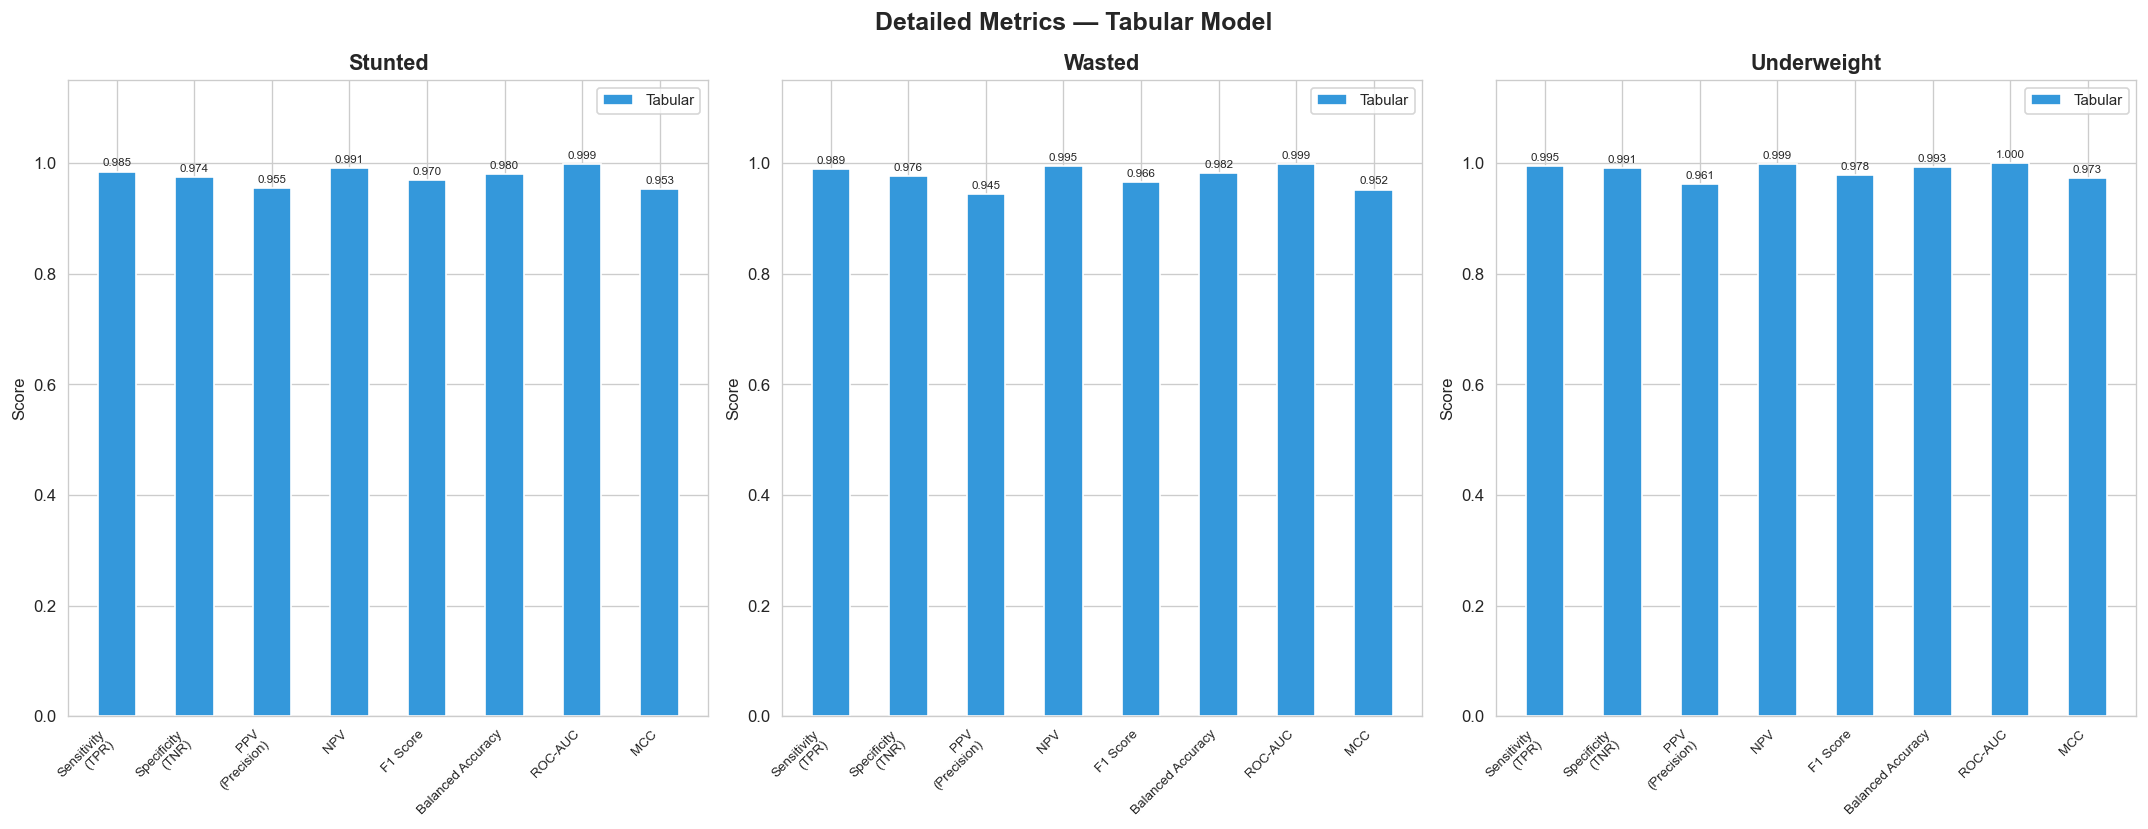

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
metrics_to_plot = [
    'Sensitivity (TPR)', 'Specificity (TNR)',
    'PPV (Precision)', 'NPV',
    'F1 Score', 'Balanced Accuracy',
    'ROC-AUC', 'MCC'
]

for ax, t in zip(axes, TARGET_COLS):
    tab_vals = [metrics_df.loc[t][m] for m in metrics_to_plot]

    x = np.arange(len(metrics_to_plot))

    ax.bar(x, tab_vals, 0.5, label='Tabular', color='#3498DB', edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' (', '\n(') for m in metrics_to_plot],
                       fontsize=8, rotation=45, ha='right')
    ax.set_title(t.capitalize(), fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    ax.set_ylabel('Score')

    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f', fontsize=7, padding=2)

plt.suptitle('Detailed Metrics — Tabular Model',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('detailed_metrics_tabular.png', bbox_inches='tight', dpi=150)
plt.show()


You should consider upgrading via the 'C:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.



SHAP Analysis: STUNTED


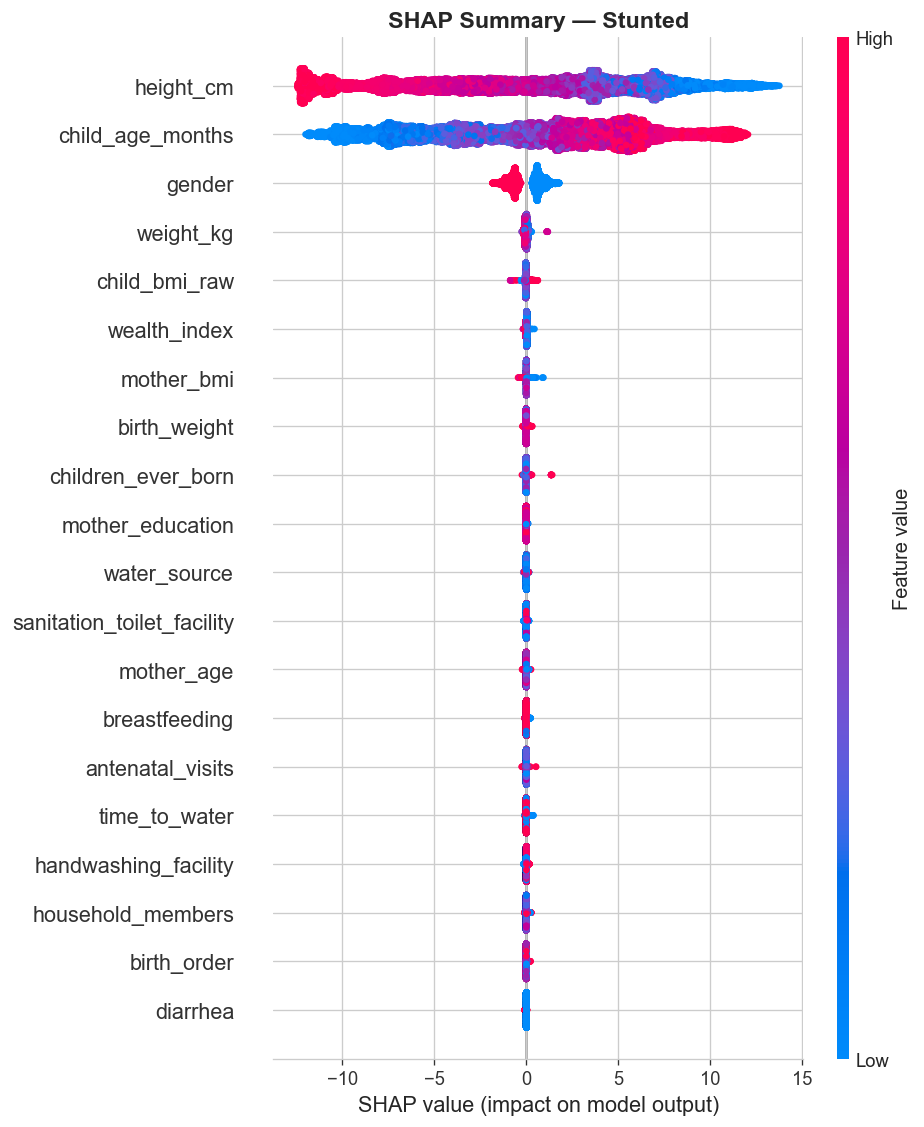

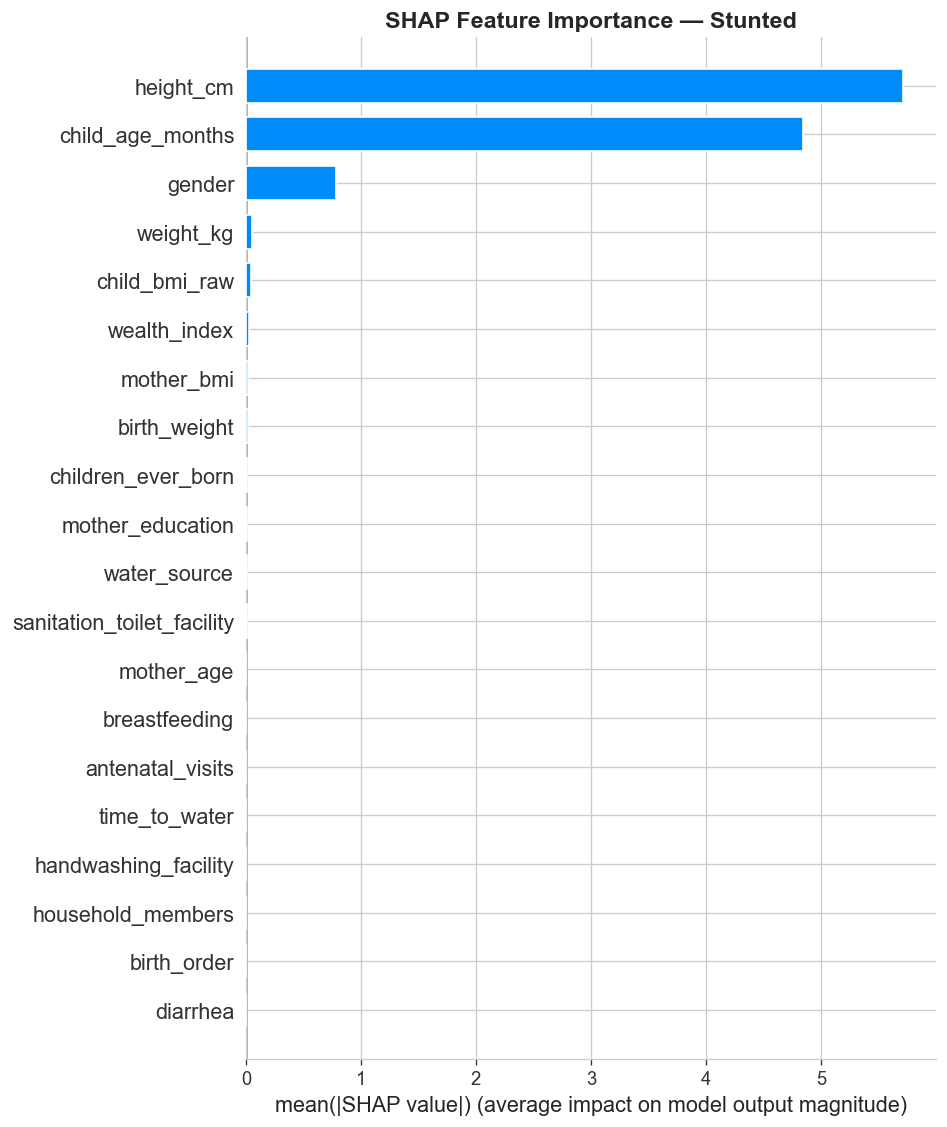


SHAP Analysis: WASTED


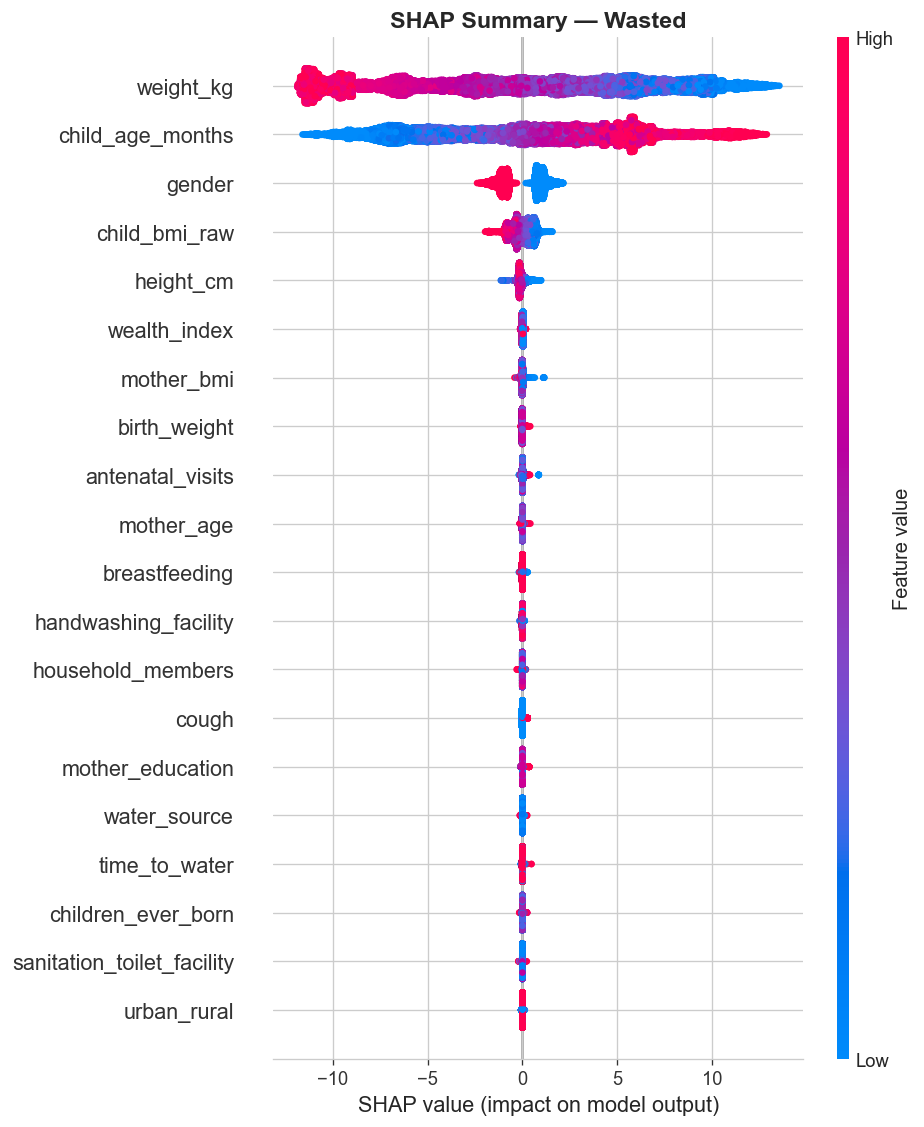

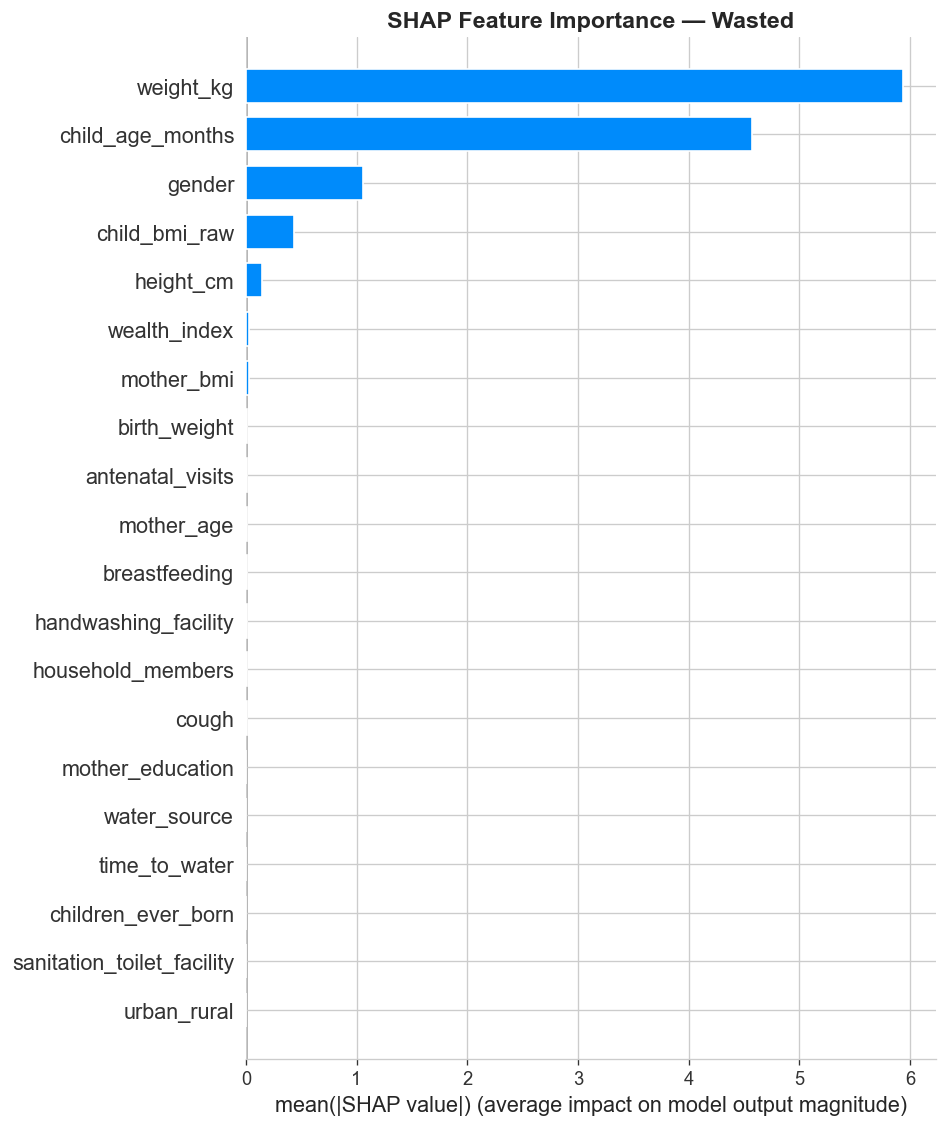


SHAP Analysis: UNDERWEIGHT


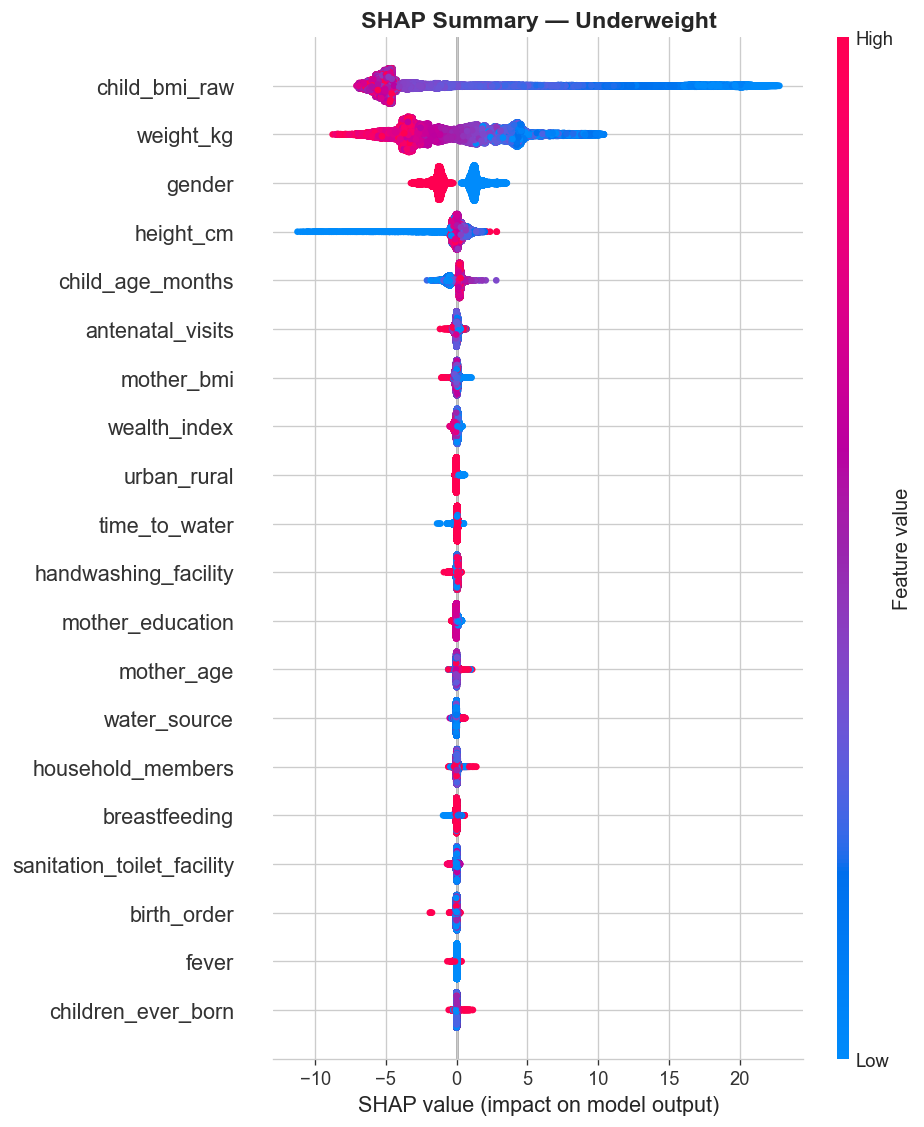

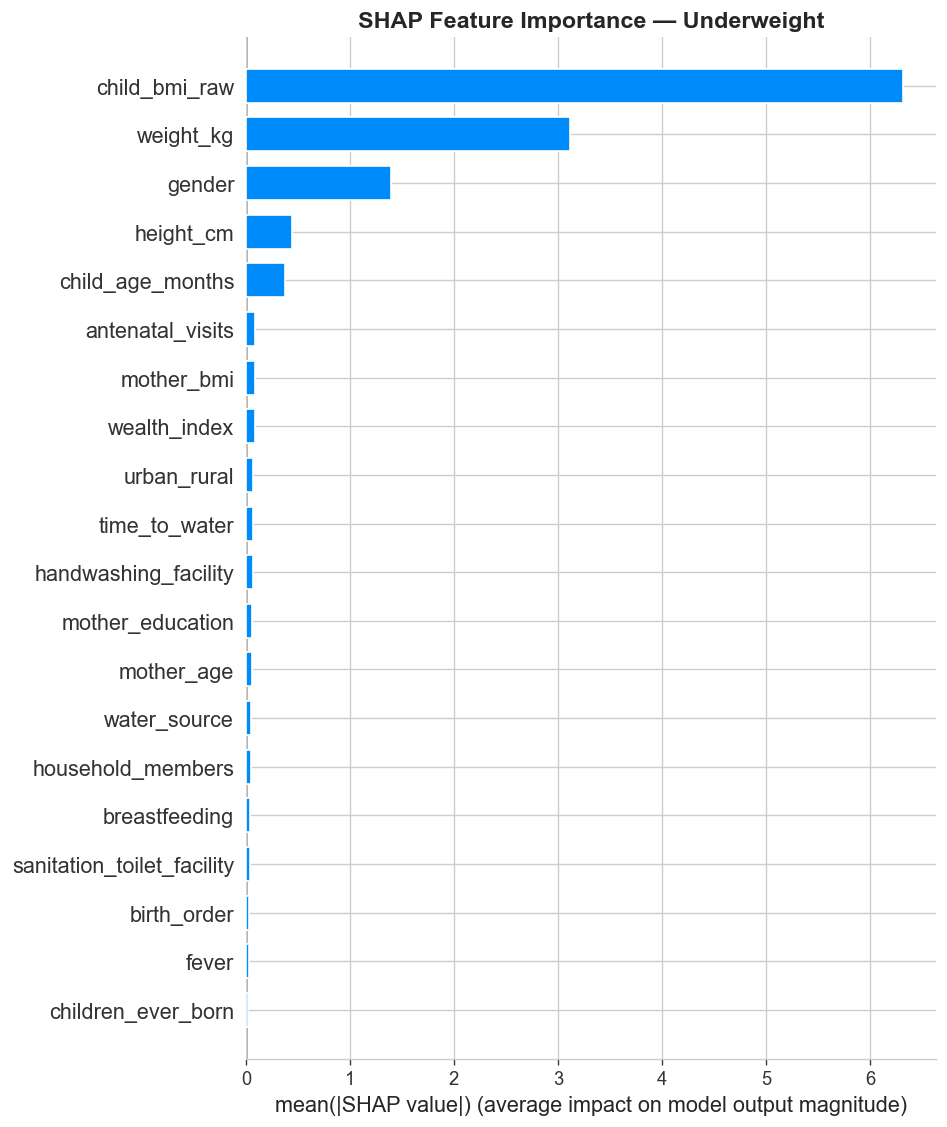

In [17]:
!pip install shap

import shap
import matplotlib.pyplot as plt

# Har target ke liye SHAP values
for t in TARGET_COLS:
    print(f"\nSHAP Analysis: {t.upper()}")

    explainer   = shap.TreeExplainer(tabular_models[t]) #explainer knows how to compute feature contributions for that model
    shap_values = explainer.shap_values(X_test) #it computes the SHAP values of every feature for every sample

    # 1. Summary plot — saare features ka importance
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values, X_test,
        feature_names=FEATURE_COLS,
        show=False
    )
    plt.title(f'SHAP Summary — {t.capitalize()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_summary_{t}.png', bbox_inches='tight', dpi=150)
    plt.show()

    # 2. Bar plot — average importance
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values, X_test,
        feature_names=FEATURE_COLS,
        plot_type='bar', show=False
    )
    plt.title(f'SHAP Feature Importance — {t.capitalize()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_bar_{t}.png', bbox_inches='tight', dpi=150)
    plt.show()
    

In [18]:
# Pehle install karo
!pip install opencv-python --quiet
print(" OpenCV installed!")

 OpenCV installed!


You should consider upgrading via the 'C:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.



Waterfall — STUNTED — Child #0


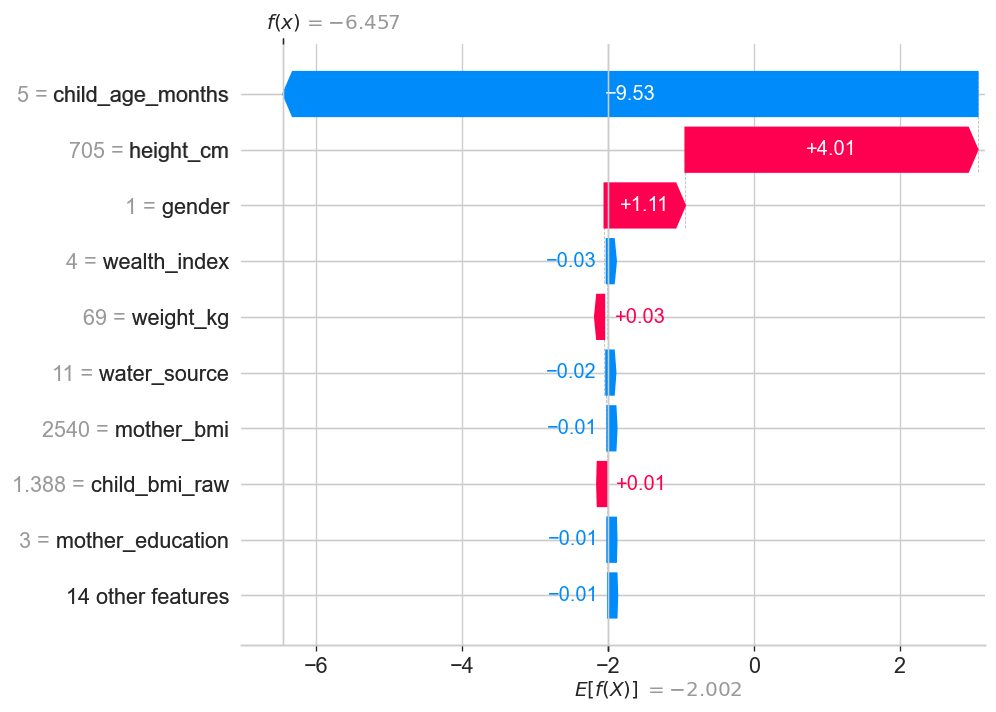


Waterfall — WASTED — Child #0


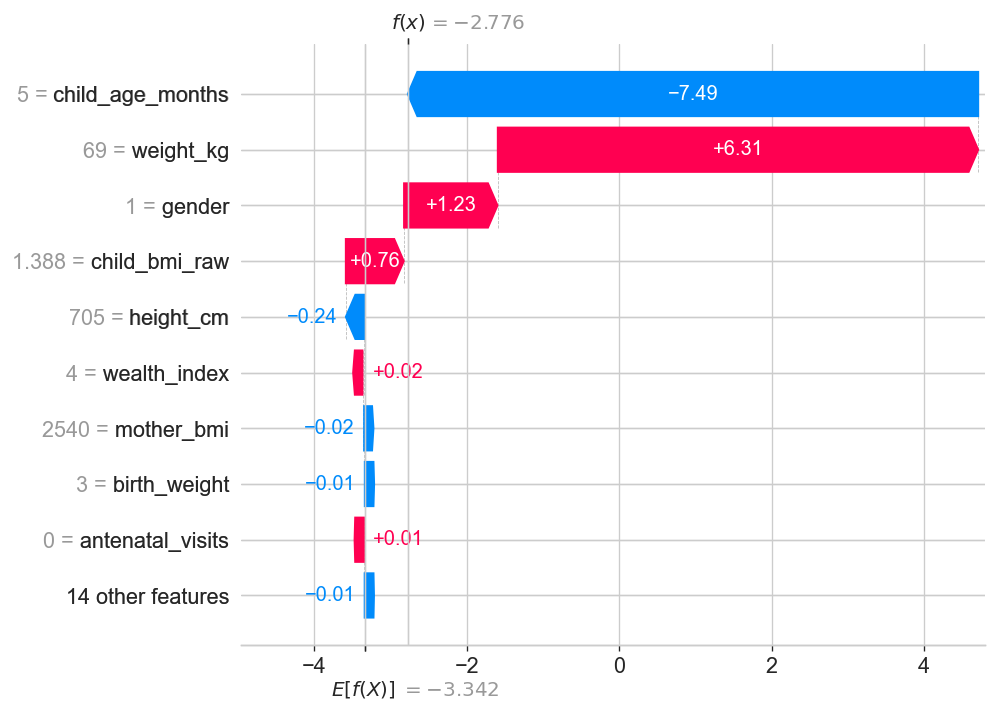


Waterfall — UNDERWEIGHT — Child #0


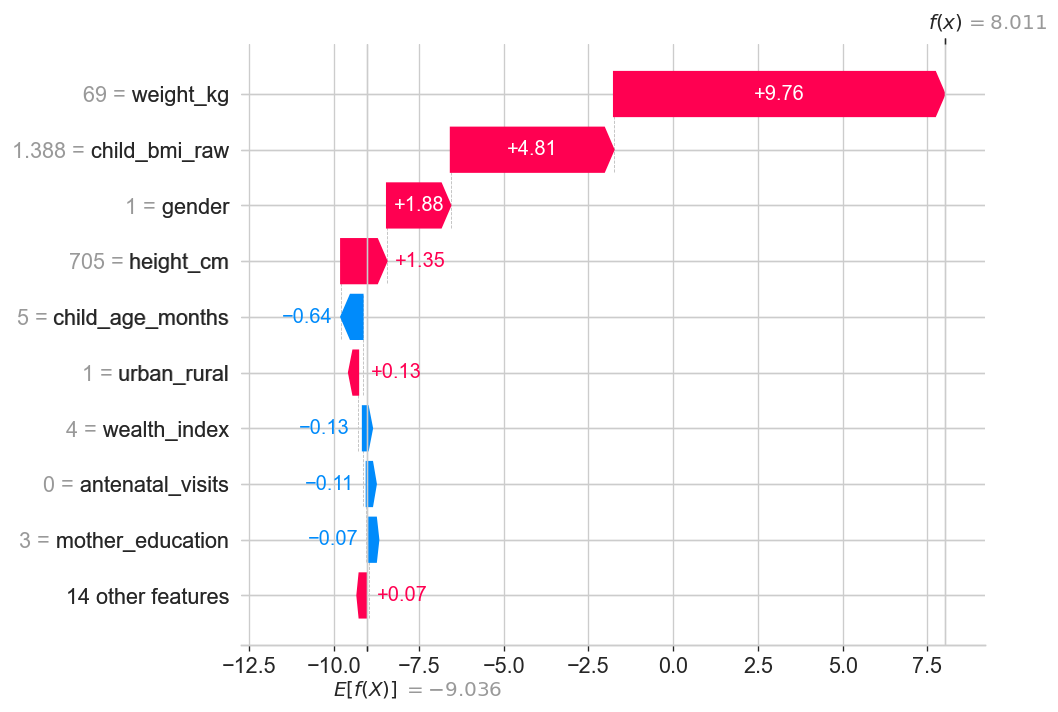

In [19]:
# ── 2. Waterfall Plot — Ek Bacche Ka Explanation ──────────
sample_idx = 0   # koi bhi test sample choose karo

for t in TARGET_COLS:
    explainer   = shap.TreeExplainer(tabular_models[t])
    shap_values = explainer.shap_values(X_test)

    print(f"\nWaterfall — {t.upper()} — Child #{sample_idx}")

    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values[sample_idx],
            base_values   = explainer.expected_value,
            data          = X_test.iloc[sample_idx].values,
            feature_names = FEATURE_COLS
        )
    )

In [20]:
# ── 3. Force Plot — Interactive ───────────────────────────
for t in TARGET_COLS:
    explainer   = shap.TreeExplainer(tabular_models[t])
    shap_values = explainer.shap_values(X_test)

    print(f"\nForce Plot — {t.upper()}")
    shap.initjs()
    display(shap.force_plot(
        explainer.expected_value,
        shap_values[0],
        X_test.iloc[0],
        feature_names=FEATURE_COLS
    ))


Force Plot — STUNTED



Force Plot — WASTED



Force Plot — UNDERWEIGHT


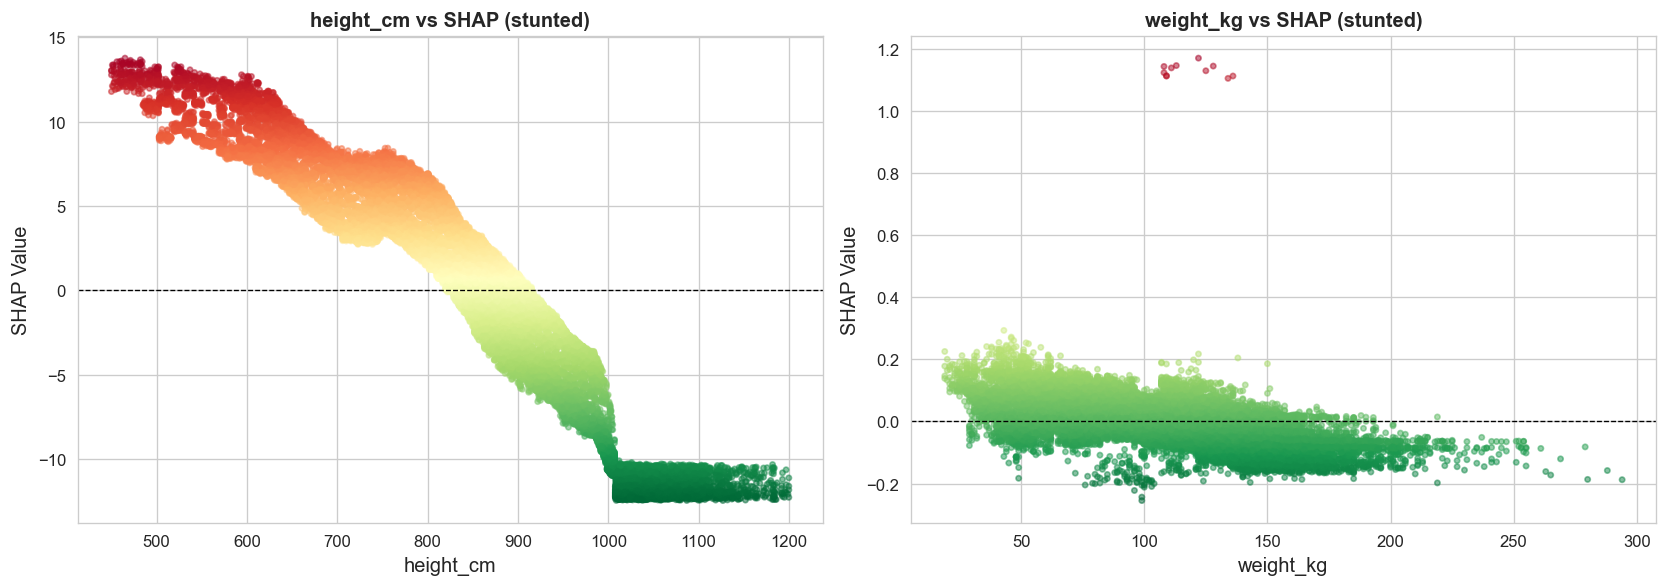

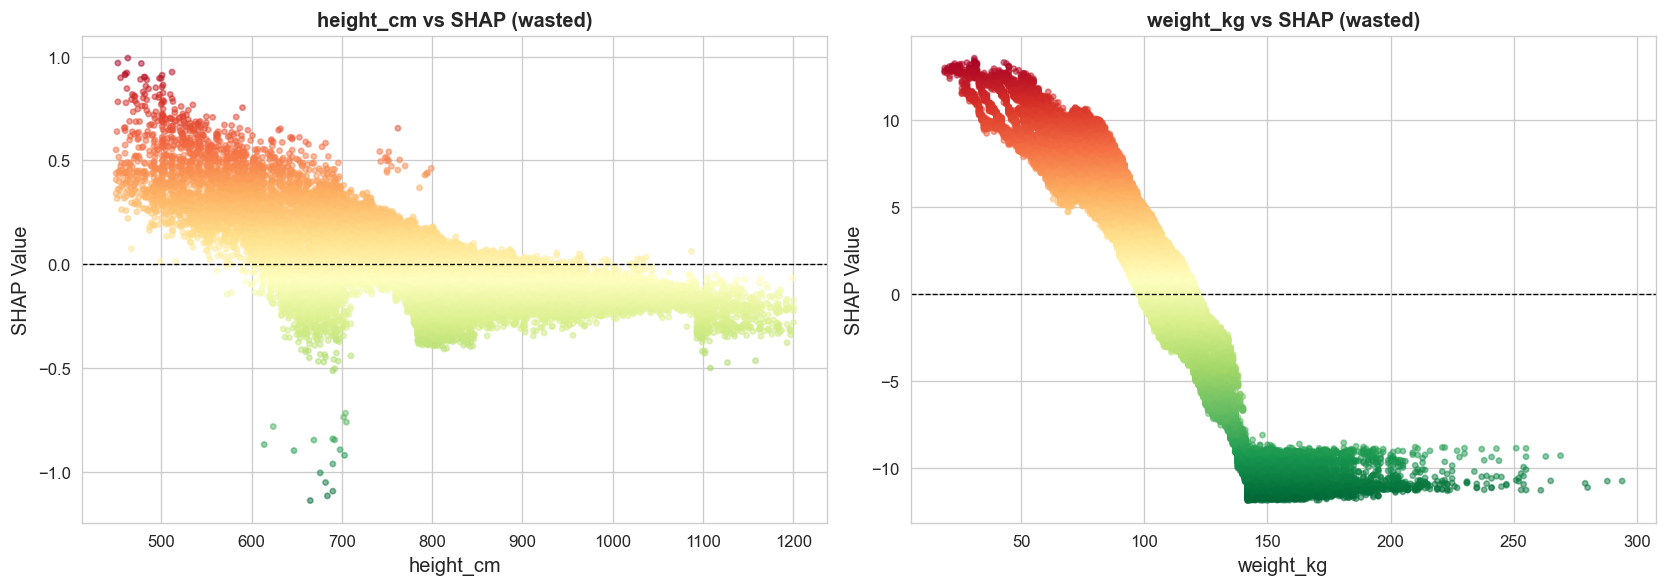

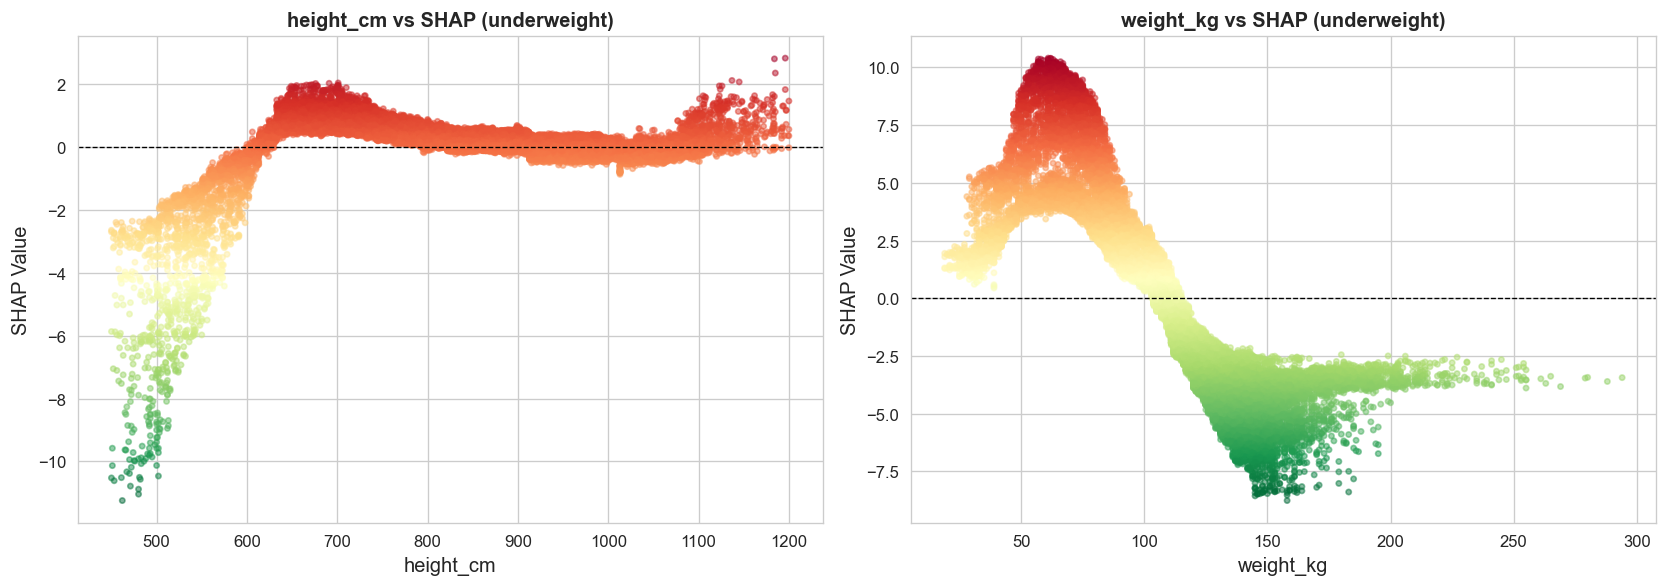

In [21]:
# ── 4. Dependence Plot — Feature vs SHAP value ────────────
# Height aur weight ka SHAP value kaise change hota hai

for t in TARGET_COLS:
    explainer   = shap.TreeExplainer(tabular_models[t])
    shap_values = explainer.shap_values(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, feat in zip(axes, ['height_cm', 'weight_kg']):
        if feat in FEATURE_COLS:
            feat_idx = FEATURE_COLS.index(feat)
            ax.scatter(
                X_test[feat],
                shap_values[:, feat_idx],
                c=shap_values[:, feat_idx],
                cmap='RdYlGn_r', alpha=0.5, s=10
            )
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
            ax.set_xlabel(feat, fontsize=12)
            ax.set_ylabel('SHAP Value', fontsize=12)
            ax.set_title(f'{feat} vs SHAP ({t})', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'shap_dependence_{t}.png', bbox_inches='tight', dpi=150)
    plt.show()

In [22]:
# Install
!pip install tensorflow --quiet

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
import os
import cv2

You should consider upgrading via the 'C:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [23]:
# ── Grad-CAM Function ──────────────────────────────────────
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):  #pred_index means which class to explain.
    """
    Grad-CAM heatmap generate karo
    img_array: preprocessed image (1, 224, 224, 3)
    """
    # Grad model banao
    # Input → last conv layer + final output
    grad_model = tf.keras.models.Model(   #why other model? Grad cam requires last conv layer output
        inputs  = model.inputs, #uses the original model input
        outputs = [
            model.get_layer(last_conv_layer_name).output,  #feature maps from the last convolutional layer
            model.output  #final prediction
        ]
    )

    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)   #last_conv returns batch,height,width,filters ; preds returns the percentage of malnourished and healthy in this case

        if pred_index is None:
            pred_index = tf.argmax(preds[0])  #ex. if prediction= 0.85 index=1 grad cam explains why the model predicts 1.

        # Predicted class ka score
        class_channel = preds[:, pred_index]  #select only the score of the predicted class

    # Gradients calculate karo
    grads = tape.gradient(class_channel, last_conv_output) #if the feature map changes, how much will the prediction change.

    # Mean gradients per filter
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)) #average over batch,height,width

    # Heatmap banao
    last_conv_output = last_conv_output[0] #remove the batch dimension because processing a single image
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    #this is a GRAD-CAM computation. Each feature map is multiplied by its corresponding importance weight and then summed.
    
    heatmap = tf.squeeze(heatmap)  #remove extra dimension
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8) #remove negative values.
    #max value =1 , min value=0

    return heatmap.numpy()  #converts the tensorflow tensor into numpy array.


def apply_gradcam(img_path, model, last_conv_layer='Conv_1'):
    #this function takes an image, generates the GRAD-CAM heatmap,overlays it on the original
    #image and returns all results.


    
    """
    Image pe Grad-CAM apply karo aur result dikhao
    """
    # Image load
    img      = keras_image.load_img(img_path, target_size=(224, 224))  #reads the image from disk and resizes it to 224*224 matching the CNN input size.
    img_arr  = keras_image.img_to_array(img) #converts the PIL image to numpy array.
    img_disp = img_arr.copy().astype('uint8')   # creates a copy so processing doesn't modify the display image.

    # Preprocess
    img_arr  = np.expand_dims(img_arr, axis=0) #add the batch dimension in it
    img_arr  = preprocess_input(img_arr)

    # Heatmap generate
    heatmap  = make_gradcam_heatmap(img_arr, model, last_conv_layer)

    # Heatmap resize karo (224×224)
    heatmap_resized = cv2.resize(heatmap, (224, 224))  #original- 7*7 resized-224*224

    # Colormap apply karo
    heatmap_colored = np.uint8(255 * heatmap_resized)   #converts values from 0-1 to 0-255 which opencv expects
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET) #adds colors- blue- low importance, green- medium importance, yellow- high importance, red-highest importance
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)  #opencv used BGR while matplotlib expects RGB

    # Original image pe overlay karo
    superimposed = heatmap_colored * 0.4 + img_disp * 0.6 #combines the original image and the heatmap
    superimposed = np.uint8(superimposed) #converts the blended image back to an 8 bit image suitable for display or saving

    return img_disp, heatmap_resized, superimposed, heatmap

In [24]:
# ── MobileNetV2 Classification Model Banao ────────────────
# (Feature extractor nahi — full model with classification head)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model

def build_cnn_classifier(num_classes=2):
    base = MobileNetV2(               # loads the pretrained MobileNetV2
        weights='imagenet',           # ImageNet ke pretrained weights
        include_top=False,            # only the convolutional layers
        input_shape=(224, 224, 3)     # image size (height, width, RGB channels)
    )

    # Sabse pehle poora base model freeze karo
    base.trainable = False

    # Last 20 layers unfreeze karo — LEKIN BatchNorm layers ko frozen hi rakho
    # (BatchNorm ko chhote dataset pe fine-tune karna training unstable kar sakta hai)
    for layer in base.layers[-20:]:
        if not isinstance(layer, BatchNormalization):
            layer.trainable = True
        else:
            layer.trainable = False   # BN stats stable rehne do

    x = base.output                                  # MobileNetV2 ke feature maps
    x = GlobalAveragePooling2D()(x)                   # overfitting kam, training fast
    x = Dense(128, activation='relu')(x)              # fully connected layer, 128 neurons
    x = Dropout(0.3)(x)                               # 30% neurons randomly off — overfitting rokta hai
    output = Dense(num_classes, activation='softmax')(x)   # final prediction (2 classes)

    model = Model(inputs=base.input, outputs=output)  # base input -> naya output layer

    model.compile(                                    # training config
        optimizer=tf.keras.optimizers.Adam(0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Model banao
cnn_classifier = build_cnn_classifier(num_classes=2)
print("CNN Classifier ready!")
print(f"Total params: {cnn_classifier.count_params():,}")

trainable_count = sum([tf.size(w).numpy() for w in cnn_classifier.trainable_weights])
print(f"Trainable params: {trainable_count:,}")

CNN Classifier ready!
Total params: 2,422,210
Trainable params: 1,359,106


In [25]:
# ── CNN Train Karo (Image data pe) ────────────────────────
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import shutil
import os

# Dono folders ke path
MALNUTRITION_DIR = r'C:\Users\hp\Videos\Downloads\archive (4)\Malnutrition'
NUTRITION_DIR     = r'C:\Users\hp\Videos\Downloads\archive (4)\Nutrition'   # <-- ye missing tha!

# Folders banao
CNN_DATA_DIR = r'C:\Users\hp\Desktop\cnn_dataset'
os.makedirs(f'{CNN_DATA_DIR}/train/malnourished', exist_ok=True)
os.makedirs(f'{CNN_DATA_DIR}/train/normal',       exist_ok=True)
os.makedirs(f'{CNN_DATA_DIR}/val/malnourished',   exist_ok=True)
os.makedirs(f'{CNN_DATA_DIR}/val/normal',         exist_ok=True)

def get_unique_images(folder):
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    seen, unique = set(), []
    for f in files:
        name = f.lower().split('.')[0].strip()
        if name not in seen:
            seen.add(name)
            unique.append(f)
    return unique

def split_and_copy(folder, class_name, split_ratio=0.8):
    imgs = get_unique_images(folder)
    split = int(len(imgs) * split_ratio)
    train_imgs = imgs[:split]
    val_imgs   = imgs[split:]
    for f in train_imgs:
        shutil.copy2(os.path.join(folder, f),
                     os.path.join(f'{CNN_DATA_DIR}/train/{class_name}', f))
    for f in val_imgs:
        shutil.copy2(os.path.join(folder, f),
                     os.path.join(f'{CNN_DATA_DIR}/val/{class_name}', f))
    return len(train_imgs), len(val_imgs)

# Dono classes copy karo
mal_train, mal_val = split_and_copy(MALNUTRITION_DIR, 'malnourished')
nor_train, nor_val = split_and_copy(NUTRITION_DIR, 'normal')

print(f"Malnourished -> Train: {mal_train} | Val: {mal_val}")
print(f"Normal       -> Train: {nor_train} | Val: {nor_val}")

# Data generators — preprocess_input use karo, rescale nahi
# (model MobileNetV2 ke sahi -1 to 1 normalization expect karta hai)
datagen_train = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen_val = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = datagen_train.flow_from_directory(
    f'{CNN_DATA_DIR}/train',
    target_size=(224, 224),
    batch_size=16,
    class_mode='sparse'
)
val_gen = datagen_val.flow_from_directory(
    f'{CNN_DATA_DIR}/val',
    target_size=(224, 224),
    batch_size=16,
    class_mode='sparse'
)

print(f"\nClass indices: {train_gen.class_indices}")  # confirm karo 0/1 ka mapping

# Train
history = cnn_classifier.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=4,
            restore_best_weights=True
        )
    ]
)

print(f"\nBest Val Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

# --- Save trained model so it can be reused for prediction later ---
cnn_classifier.save('cnn_malnutrition_model.keras')
print("CNN model saved to cnn_malnutrition_model.keras")


Malnourished -> Train: 760 | Val: 191
Normal       -> Train: 801 | Val: 201
Found 1561 images belonging to 2 classes.
Found 392 images belonging to 2 classes.

Class indices: {'malnourished': 0, 'normal': 1}
Epoch 1/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9161 - loss: 0.2042 - val_accuracy: 0.9694 - val_loss: 0.0662
Epoch 2/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9609 - loss: 0.1042 - val_accuracy: 0.9694 - val_loss: 0.0915
Epoch 3/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 115s 791ms/step - accuracy: 0.9571 - loss: 0.1131 - val_accuracy: 0.9031 - val_loss: 0.1782
Epoch 4/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 90s 918ms/step - accuracy: 0.9782 - loss: 0.0559 - val_accuracy: 0.9413 - val_loss: 0.1169
Epoch 5/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9859 - loss: 0.0455 - val_accuracy: 0.9643 - val_loss: 0.0834

Best Val Accuracy: 96.94%
CNN model saved to cnn_malnutrition_model.keras


In [26]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

# Load the TRAINED model (saved at the end of the training cell above)
cnn_classifier_loaded = tf.keras.models.load_model('cnn_malnutrition_model.keras')

# Must match train_gen.class_indices printed during training
CLASS_INDICES = {'malnourished': 0, 'normal': 1}
IDX_TO_CLASS = {v: k for k, v in CLASS_INDICES.items()}

def predict_image(img_path, model=cnn_classifier_loaded, class_indices=CLASS_INDICES):
    """
    Predict malnutrition status for a single image.
    Uses the SAME preprocessing as training (preprocess_input, NOT /255 rescale).
    """
    img = keras_image.load_img(img_path, target_size=(224, 224))
    arr = keras_image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)

    pred = model.predict(arr, verbose=0)[0]
    idx_to_class = {v: k for k, v in class_indices.items()}
    pred_idx = int(np.argmax(pred))
    label = idx_to_class[pred_idx].capitalize()
    conf = pred[pred_idx] * 100
    return label, conf, pred

# Example usage:
# label, conf, raw_probs = predict_image('path/to/your/image.jpg')
# print(f"Prediction: {label} ({conf:.1f}% confidence)")


In [27]:
# Quick sanity check on a few validation images from both classes
import glob

check_images = (
    glob.glob(f'{CNN_DATA_DIR}/val/malnourished/*')[:3] +
    glob.glob(f'{CNN_DATA_DIR}/val/normal/*')[:3]
)

for img_path in check_images:
    label, conf, _ = predict_image(img_path)
    print(f"{img_path} -> {label} ({conf:.1f}%)")


C:\Users\hp\Desktop\cnn_dataset/val/malnourished\Malnurished (784).jpg -> Malnourished (88.7%)
C:\Users\hp\Desktop\cnn_dataset/val/malnourished\Malnurished (785).jpg -> Malnourished (99.8%)
C:\Users\hp\Desktop\cnn_dataset/val/malnourished\Malnurished (786).jpg -> Malnourished (98.5%)
C:\Users\hp\Desktop\cnn_dataset/val/normal\NU (818).jpg -> Normal (99.9%)
C:\Users\hp\Desktop\cnn_dataset/val/normal\NU (819).jpg -> Normal (100.0%)
C:\Users\hp\Desktop\cnn_dataset/val/normal\NU (82).jpg -> Normal (93.8%)


In [28]:
import os

# Option 1: Agar tumne pichhle notebook cell mein CNN_DATA_DIR already define kiya tha,
# to seedha check karo uska current value
try:
    print("Current CNN_DATA_DIR:", CNN_DATA_DIR)
    print("Exists?", os.path.exists(CNN_DATA_DIR))
except NameError:
    print("CNN_DATA_DIR variable is not defined in this session")

Current CNN_DATA_DIR: C:\Users\hp\Desktop\cnn_dataset
Exists? True


In [29]:
import os

for split in ['train', 'val']:
    for cls in ['malnourished', 'normal']:
        folder = os.path.join(CNN_DATA_DIR, split, cls)
        if os.path.exists(folder):
            count = len([f for f in os.listdir(folder) 
                        if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
            print(f"{split}/{cls}: {count} images")
        else:
            print(f"{split}/{cls}: FOLDER MISSING")

train/malnourished: 760 images
train/normal: 801 images
val/malnourished: 191 images
val/normal: 201 images


In [30]:
# ── Grad-CAM Function ──────────────────────────────────────
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs  = model.inputs,
        outputs = [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )
    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def apply_gradcam(img_path, model, last_conv_layer='Conv_1'):
    img      = keras_image.load_img(img_path, target_size=(224, 224))
    img_arr  = keras_image.img_to_array(img)
    img_disp = img_arr.copy().astype('uint8')
    img_arr  = np.expand_dims(img_arr, axis=0)
    img_arr  = preprocess_input(img_arr)
    heatmap  = make_gradcam_heatmap(img_arr, model, last_conv_layer)
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    superimposed = heatmap_colored * 0.4 + img_disp * 0.6
    superimposed = np.uint8(superimposed)
    return img_disp, heatmap_resized, superimposed, heatmap

Total samples: 6 (Malnourished: 3, Normal: 3)


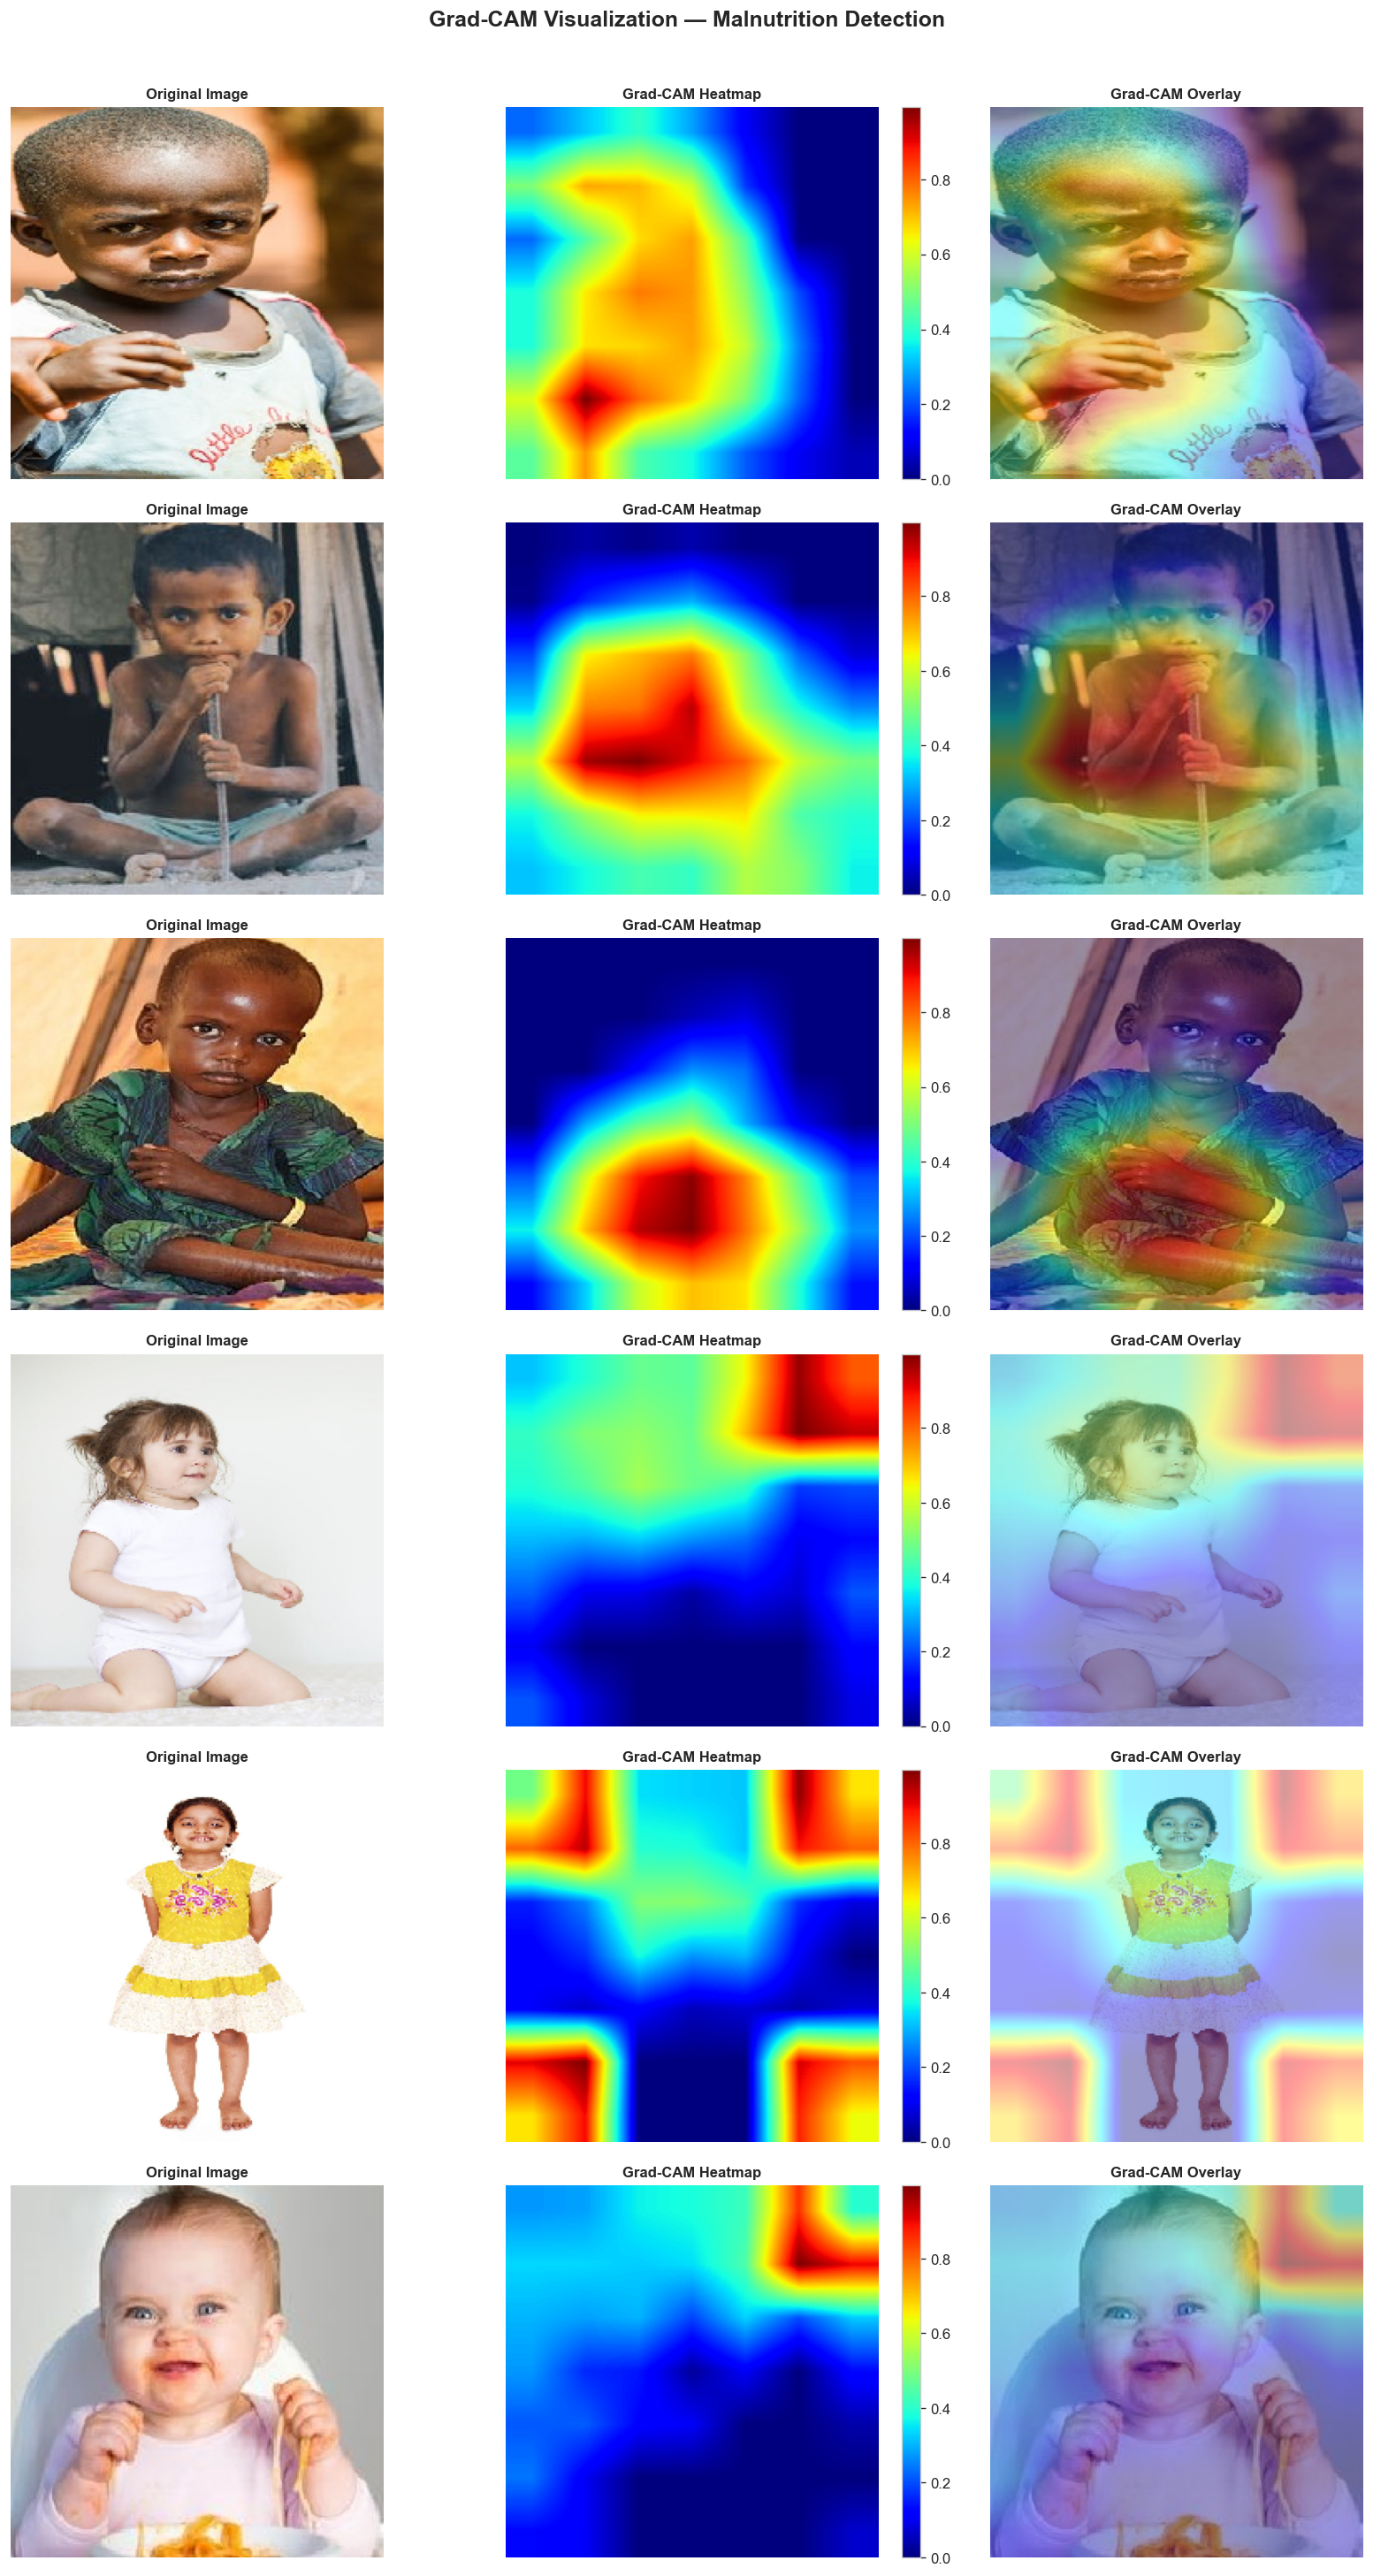

Saved: gradcam_results.png


In [31]:
# ── Grad-CAM Visualize Karo ────────────────────────────────
import glob

mal_samples = glob.glob(f'{CNN_DATA_DIR}/val/malnourished/*')[:3]
nor_samples = glob.glob(f'{CNN_DATA_DIR}/val/normal/*')[:3]
sample_images = mal_samples + nor_samples

print(f"Total samples: {len(sample_images)} (Malnourished: {len(mal_samples)}, Normal: {len(nor_samples)})")

fig, axes = plt.subplots(len(sample_images), 3,
                          figsize=(14, len(sample_images) * 4))

for i, img_path in enumerate(sample_images):
    original, heatmap, superimposed, raw_heat = apply_gradcam(
        img_path, cnn_classifier, last_conv_layer='Conv_1'
    )

    axes[i, 0].imshow(original)
    axes[i, 0].set_title('Original Image', fontsize=10, fontweight='bold')
    axes[i, 0].axis('off')

    im = axes[i, 1].imshow(heatmap, cmap='jet')
    axes[i, 1].set_title('Grad-CAM Heatmap', fontsize=10, fontweight='bold')
    axes[i, 1].axis('off')
    plt.colorbar(im, ax=axes[i, 1], fraction=0.046)

    axes[i, 2].imshow(superimposed)
    axes[i, 2].set_title('Grad-CAM Overlay', fontsize=10, fontweight='bold')
    axes[i, 2].axis('off')

plt.suptitle('Grad-CAM Visualization — Malnutrition Detection',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gradcam_results.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: gradcam_results.png")

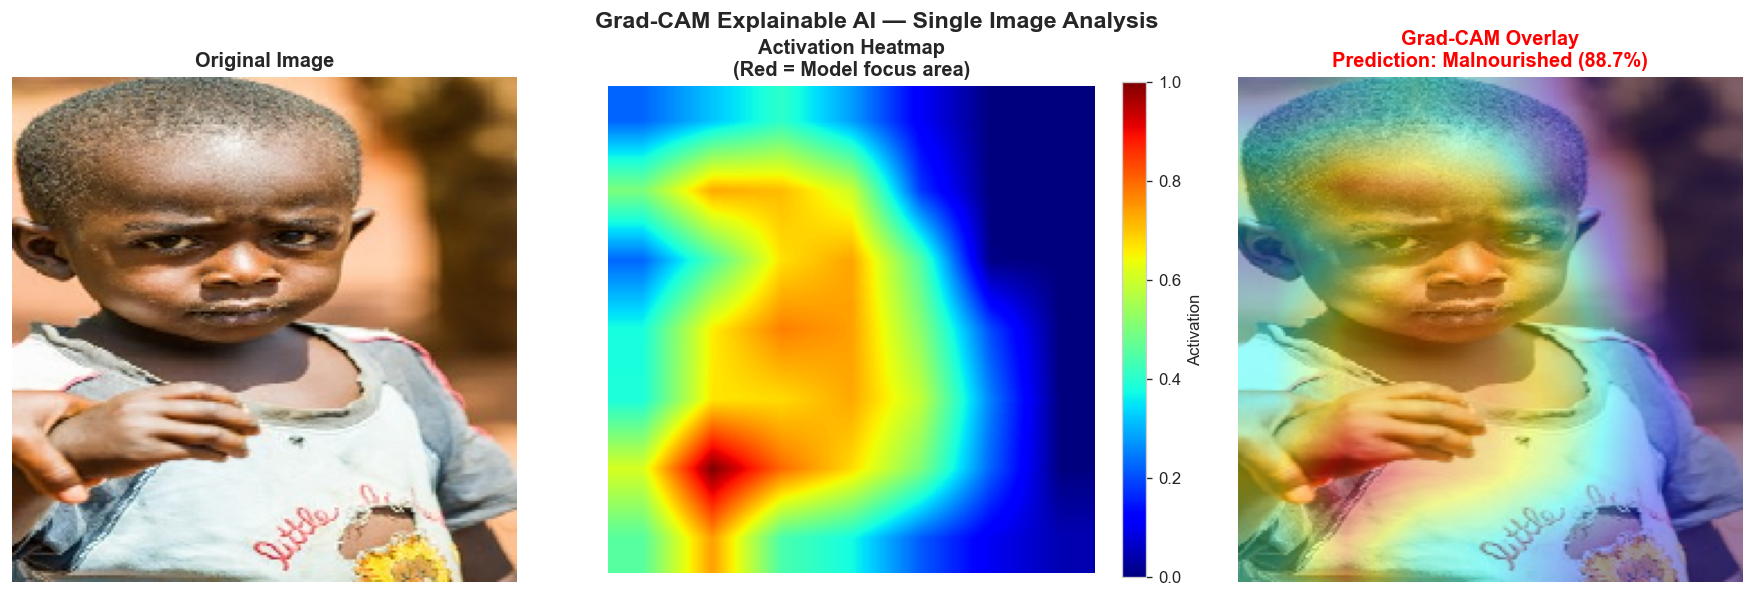

Prediction: Malnourished (88.7% confidence)
Saved: gradcam_single.png


In [32]:
# ── Single Image Detailed Analysis ────────────────────────
def analyze_single_image(img_path, model, class_indices, save_name='gradcam_single.png'):
    """
    Ek image ka detailed Grad-CAM analysis
    class_indices: train_gen.class_indices se (e.g. {'malnourished':0, 'normal':1})
    """
    original, heatmap, superimposed, _ = apply_gradcam(
        img_path, model, 'Conv_1'
    )

    # Prediction bhi lo
    img      = keras_image.load_img(img_path, target_size=(224, 224))
    img_arr  = keras_image.img_to_array(img)
    img_arr  = np.expand_dims(img_arr, axis=0)
    img_arr  = preprocess_input(img_arr)
    pred     = model.predict(img_arr, verbose=0)[0]

    # Sahi tarike se index -> class name map karo (hardcode mat karo)
    idx_to_class = {v: k for k, v in class_indices.items()}
    pred_idx = int(np.argmax(pred))
    label = idx_to_class[pred_idx].capitalize()
    conf = pred[pred_idx] * 100

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    im = axes[1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Activation Heatmap\n(Red = Model focus area)',
                      fontsize=12, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, label='Activation')

    axes[2].imshow(superimposed)
    axes[2].set_title(f'Grad-CAM Overlay\nPrediction: {label} ({conf:.1f}%)',
                      fontsize=12, fontweight='bold',
                      color='red' if label.lower() == 'malnourished' else 'green')
    axes[2].axis('off')

    plt.suptitle('Grad-CAM Explainable AI — Single Image Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Prediction: {label} ({conf:.1f}% confidence)")
    print(f"Saved: {save_name}")

# Test karo — seedha cnn_dataset validation folder se image lo
import glob
test_img = glob.glob(f'{CNN_DATA_DIR}/val/malnourished/*')[0]
analyze_single_image(test_img, cnn_classifier, class_indices=train_gen.class_indices)

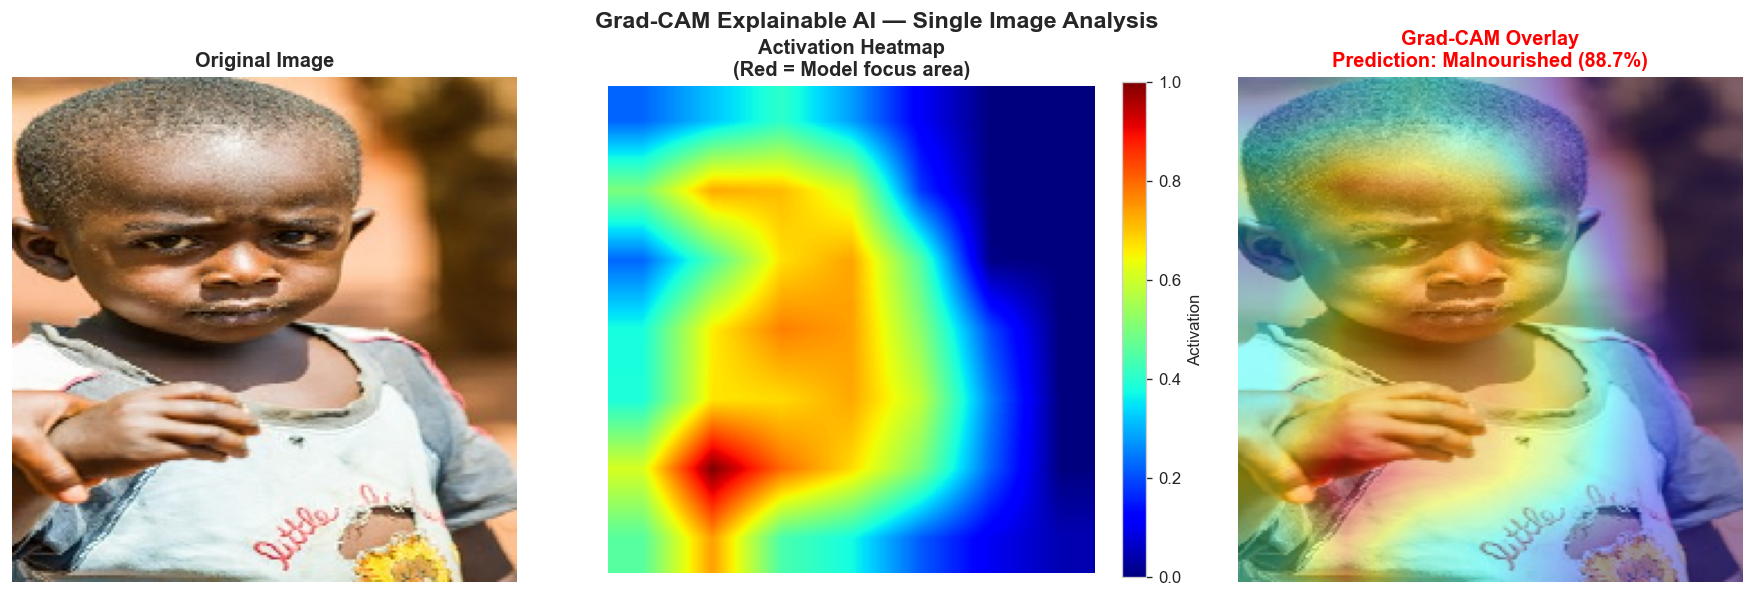

Prediction: Malnourished (88.7% confidence)
Saved: gradcam_single.png


In [33]:
# ── Single Image Detailed Analysis ────────────────────────
def analyze_single_image(img_path, model, class_indices, save_name='gradcam_single.png'):
    """
    Ek image ka detailed Grad-CAM analysis
    class_indices: train_gen.class_indices se (e.g. {'malnourished':0, 'normal':1})
    """
    original, heatmap, superimposed, _ = apply_gradcam(
        img_path, model, 'Conv_1'
    )

    # Prediction bhi lo
    img      = keras_image.load_img(img_path, target_size=(224, 224))
    img_arr  = keras_image.img_to_array(img)
    img_arr  = np.expand_dims(img_arr, axis=0)
    img_arr  = preprocess_input(img_arr)
    pred     = model.predict(img_arr, verbose=0)[0]

    # Sahi tarike se index -> class name map karo (hardcode mat karo)
    idx_to_class = {v: k for k, v in class_indices.items()}
    pred_idx = int(np.argmax(pred))
    label = idx_to_class[pred_idx].capitalize()
    conf = pred[pred_idx] * 100

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    im = axes[1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Activation Heatmap\n(Red = Model focus area)',
                      fontsize=12, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, label='Activation')

    axes[2].imshow(superimposed)
    axes[2].set_title(f'Grad-CAM Overlay\nPrediction: {label} ({conf:.1f}%)',
                      fontsize=12, fontweight='bold',
                      color='red' if label.lower() == 'malnourished' else 'green')
    axes[2].axis('off')

    plt.suptitle('Grad-CAM Explainable AI — Single Image Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Prediction: {label} ({conf:.1f}% confidence)")
    print(f"Saved: {save_name}")

# Test karo — seedha cnn_dataset validation folder se image lo
import glob
test_img = glob.glob(f'{CNN_DATA_DIR}/val/malnourished/*')[0]
analyze_single_image(test_img, cnn_classifier, class_indices=train_gen.class_indices)

In [35]:
!python --version

Python 3.10.0


In [36]:
import sklearn
import numpy
import joblib

print(sklearn.__version__)
print(numpy.__version__)
print(joblib.__version__)

1.7.2
2.2.6
1.5.3


In [37]:
import tensorflow as tf
print(tf.__version__)

2.21.0
